<a href="https://colab.research.google.com/github/Ramnareshkuri01/Python/blob/main/Mild_dementia_correlation_LASI_DAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [160]:
import pandas as pd
data = pd.read_stata("/content/H_LASI_DAD_b1.dta")
print(", ".join(data.columns))



prim_key, hhid, pnc, pn, isoa3, r1stateid, r2stateid, inhcap1, inhcap2, r1phase, r2phase, r2module, r1hiwstat, r2hiwstat, r1hiwstat_d, r2hiwstat_d, r1hwtresp, r2hwtresp, r2hlwtresp, r1hiwy, r2hiwy, r1hiwm, r2hiwm, r1lasidy, r2lasidy, r2daddy, r1hlang_d, r2hlang_d, rabyear, rabmonth, r1hagey, r2hagey, ragender, rafgendr, r1hcastec, r2hcastec, raeduc_l, raeducel, raeducl, raedyrs, r1illiterate, r2illiterate, r1hmstatc, r1hmstathc, r2hmstathc, r2hmstat, r2fhmstat_d, r1hruralc, r2hruralc, r1urid, r2urid, r1obsnoise, r2obsnoise, r1obsodor, r2obsodor, r1obsair, r2obsair, r1obshouse, r2obshouse, r1hmo, r2hmo, r1fhmo, r2fhmo, r1hyr, r2hyr, r1fhyr, r2fhyr, r1hdw, r2hdw, r1fhdw, r2fhdw, r1hseason, r2hseason, r1fhseason, r2fhseason, r1hdate, r2hdate, r1fhdate, r2fhdate, r1orient_t5, r2orient_t5, r1orient_t4, r2orient_t4, r1hstate, r2hstate, r1fhstate, r2fhstate, r1hcity, r2hcity, r1fhcity, r2fhcity, r1hfloor, r1fhfloor, r2hhome, r2fhhome, r1hname, r1fhname, r2hdistrict, r2fhdistrict, r1haddress, 

In [163]:
data.shape

(6168, 1706)

In [167]:
# ======================================================
# FULL CLINICAL FEATURE MAP  (concept → r1/r2 names)
# ======================================================

feature_map = {

    # ------------------
    # Demographic
    # ------------------
    "age": ["r1hagey","r2hagey"],
    "gender": ["ragender"],
    "education": ["raedyrs"],
    "rural": ["r1hruralc","r2hruralc"],


    # ------------------
    # Cognition (core)
    # ------------------
    "orientation": ["r1borient","r2borient"],
    "executive": ["r1bexefu","r2bexefu"],
    "language": ["r1blangf","r2blangf"],
    "memory": ["r1bmemory","r2bmemory"],
    "visuospatial": ["r1bvsp","r2bvsp"],
    "global_cog": ["r1sgcp","r2sgcp"],

    "hmse": ["r1hmse_scorz","r2hmse_scorz"],
    "word_total": ["r1word_totaz","r2word_totaz"],
    "word_delay": ["r1word_dz","r2word_dz"],
    "recognition": ["r1wre_scorez","r2wre_scorez"],
    "logical_memory": ["r1log_recoz","r2log_recoz"],
    "imm_memory": ["r1bm_immexz","r2bm_immexz"],
    "del_memory": ["r1bm_reclexz","r2bm_reclexz"],
    "verbal": ["r1verbalz","r2verbalz"],
    "reasoning": ["r1rv_scorez","r2rv_scorez"],


    # ------------------
    # Vitals
    # ------------------
    "systolic": ["r1hsysto","r2hsysto"],
    "diastolic": ["r1hdiasto","r2hdiasto"],
    "pulse": ["r1hpulse","r2hpulse"],
    "hypertension": ["r1bphigh","r2bphigh"],


    # ------------------
    # Body composition
    # ------------------
    "height": ["r1hmheight","r2hmheight"],
    "weight": ["r1hmweight","r2hmweight"],
    "bmi": ["r1hmbmi","r2hmbmi"],
    "bmi_category": ["r1hmbmicat_d","r2hmbmicat_d"],


    # ------------------
    # Functional disability
    # ------------------
    "adl": ["r1hadltot6","r2hadltot6"],
    "iadl": ["r1hiadltot1_d","r2hiadltot1_d"],


    # ------------------
    # Mental health
    # ------------------
    "depression": ["r1hcesdl10","r2hcesdl10"],
    "anxiety": ["r1anx5","r2anx5"],


    # ------------------
    # Hearing
    # ------------------
    "hearing": ["r1i_hear","r2i_hear"],
    "hearing_aid": ["r1hhear_aid"],


    # ------------------
    # Labs / biomarkers
    # ------------------
    "albumin": ["r1albumin","r2albumin"],
    "agratio": ["r1agratio","r2agratio"],
    "alt": ["r1alt","r2alt"],
    "ast": ["r1ast","r2ast"],
    "alp": ["r1alp","r2alp"],
    "platelet": ["r1platelet","r2platelet"],
    "pcv": ["r1pcv","r2pcv"],
    "diabetes": ["r1diabetes","r2diabetes"],
    "anemia": ["r1anemia","r2anemia"]
}


# ======================================================
# AUTO SELECT AVAILABLE VARIABLES
# ======================================================

selected_cols = []
missing = []

for name, options in feature_map.items():
    found = [c for c in options if c in data.columns]

    if found:
        selected_cols.append(found[0])  # pick first existing
    else:
        missing.append(name)


data = data[selected_cols]

print("\n✅ Selected columns:")
print(selected_cols)

print("\n❌ Missing concepts:")
print(missing)

print("\nFinal shape:", data.shape)



✅ Selected columns:
['r1hagey', 'ragender', 'raedyrs', 'r1hruralc', 'r1borient', 'r1bexefu', 'r1blangf', 'r1bmemory', 'r1bvsp', 'r1sgcp', 'r1hmse_scorz', 'r1word_totaz', 'r1word_dz', 'r1wre_scorez', 'r1log_recoz', 'r1bm_immexz', 'r1bm_reclexz', 'r1verbalz', 'r1rv_scorez', 'r1hsysto', 'r1hdiasto', 'r1hpulse', 'r1bphigh', 'r1hmheight', 'r1hmweight', 'r1hmbmi', 'r1hmbmicat_d', 'r1hadltot6', 'r1hiadltot1_d', 'r1hcesdl10', 'r1anx5', 'r1i_hear', 'r1hhear_aid', 'r1albumin', 'r1agratio', 'r1alt', 'r1ast', 'r1alp', 'r1platelet', 'r1pcv', 'r1diabetes', 'r1anemia']

❌ Missing concepts:
[]

Final shape: (6168, 42)


In [168]:

# =====================================================
# 2. SPLIT NUMERIC + CATEGORICAL  (IMPORTANT)
# =====================================================

num_df = data.select_dtypes(include=['int64','float64']).copy()
cat_df = data.select_dtypes(include=['object','category']).copy()

print("Numeric:", num_df.shape)
print("Categorical:", cat_df.shape)


Numeric: (6168, 22)
Categorical: (6168, 10)


In [169]:

# =====================================================
# 3. DROP BAD COLUMNS (>60% missing)
# =====================================================

threshold = 0.6

num_df = num_df.loc[:, num_df.isnull().mean() < threshold]
cat_df = cat_df.loc[:, cat_df.isnull().mean() < threshold]



# =====================================================
# 4. DROP BAD ROWS (>50% missing)
# =====================================================

row_thresh = int(0.5 * num_df.shape[1])

num_df = num_df.dropna(thresh=row_thresh)
cat_df = cat_df.loc[num_df.index]

# reset index (clean)
num_df = num_df.reset_index(drop=True)
cat_df = cat_df.reset_index(drop=True)

In [170]:

# =====================================================
# 5. ITERATIVE IMPUTATION (numeric only)
# =====================================================

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imp = IterativeImputer(
    max_iter=10,
    n_nearest_features=25,
    initial_strategy='median',
    random_state=0
)

num_df[:] = imp.fit_transform(num_df)


In [171]:


# =====================================================
# 6. MODE IMPUTATION (categorical)
# =====================================================

for col in cat_df.columns:
    cat_df[col] = cat_df[col].fillna(cat_df[col].mode()[0])


In [172]:
# =====================================================
# 7. ONE-HOT ENCODING (ONLY categorical)
# =====================================================

from sklearn.preprocessing import OneHotEncoder

cat_df = cat_df.astype(str)   # safe for encoding

encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

cat_encoded = encoder.fit_transform(cat_df)

encoded_cols = encoder.get_feature_names_out(cat_df.columns)

cat_encoded_df = pd.DataFrame(
    cat_encoded,
    columns=encoded_cols,
    index=cat_df.index
)

In [173]:
# =====================================================
# 8. COMBINE
# =====================================================

final_df = pd.concat([num_df, cat_encoded_df], axis=1)

print("Final:", final_df.shape)


Final: (4096, 47)


In [174]:
final_df.head()

,r1hagey,r1borient,r1bexefu,r1blangf,r1bmemory,r1bvsp,r1sgcp,r1hmse_scorz,r1word_totaz,r1word_dz,r1wre_scorez,r1log_recoz,r1bm_immexz,r1bm_reclexz,r1verbalz,r1rv_scorez,r1hcesdl10,r1anx5,r1alt,r1ast,r1alp,r1platelet,ragender_2.Woman,r1hruralc_1.rural village,r1bphigh_1.Yes,r1hmbmicat_d_1.normal weight (18.5-24.9),r1hmbmicat_d_2.overweight (25.0-29.9),r1hmbmicat_d_3.obese (30.0 and greater),r1hadltot6_1,r1hadltot6_2,r1hadltot6_3,r1hadltot6_4,r1hadltot6_5,r1hadltot6_6,r1hiadltot1_d_1,r1hiadltot1_d_2,r1hiadltot1_d_3,r1hiadltot1_d_4,r1hiadltot1_d_5,r1hiadltot1_d_6,r1hiadltot1_d_7,r1i_hear_1.Difficulty hearing only,r1i_hear_2.Difficulty seeing only,r1i_hear_3.Difficulty hearing & seeing,r1hhear_aid_1.yes,r1diabetes_1.Yes,r1anemia_1.Yes
0,68.0,0.955,-0.706,0.340,-0.714,-1.383,-0.392,0.074081,-0.096435,0.397481,-1.680023,-2.375594,-0.046611,-0.738371,1.896792,-0.447691,13.00000,4.000000,18.702986,26.090862,94.600845,227.650878,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,69.0,-1.876,-1.356,-1.236,-1.580,-0.942,-1.806,-2.282337,-1.270281,-1.329469,-1.680023,-0.147494,-1.278338,-0.738371,-2.475944,-1.050995,14.00000,2.000000,16.089870,26.545381,104.303156,232.222302,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,61.0,0.955,-0.036,-0.122,0.350,0.704,0.378,0.799132,1.077411,-0.034257,0.841551,0.489107,-0.046611,-0.738371,1.678155,-0.146039,18.00000,3.000000,21.699002,26.942963,93.953272,232.720406,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,61.0,-2.523,-2.221,-3.294,-2.474,-1.383,-3.164,-3.913703,-2.248486,-1.329469,-4.481773,-2.375594,-1.278338,-0.738371,-2.475944,-2.257604,15.11176,5.630458,16.308734,28.031922,113.127672,233.442680,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,69.0,0.955,1.489,1.266,0.550,1.285,1.370,0.617869,0.881770,-0.465994,0.841551,-0.147494,1.800981,1.745199,1.022244,0.155613,14.00000,0.000000,20.724917,25.838500,88.575300,219.972064,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [175]:
# =====================================================
# 9. SCALE (mandatory before PCA/SVM)
# =====================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(final_df)


print("Scaled:", X_scaled.shape)


Scaled: (4096, 47)


In [181]:
print(", ".join(final_df.columns))


r1hagey, r1borient, r1bexefu, r1blangf, r1bmemory, r1bvsp, r1sgcp, r1hmse_scorz, r1word_totaz, r1word_dz, r1wre_scorez, r1log_recoz, r1bm_immexz, r1bm_reclexz, r1verbalz, r1rv_scorez, r1hcesdl10, r1anx5, r1alt, r1ast, r1alp, r1platelet, ragender_2.Woman, r1hruralc_1.rural village, r1bphigh_1.Yes, r1hmbmicat_d_1.normal weight (18.5-24.9), r1hmbmicat_d_2.overweight (25.0-29.9), r1hmbmicat_d_3.obese (30.0 and greater), r1hadltot6_1, r1hadltot6_2, r1hadltot6_3, r1hadltot6_4, r1hadltot6_5, r1hadltot6_6, r1hiadltot1_d_1, r1hiadltot1_d_2, r1hiadltot1_d_3, r1hiadltot1_d_4, r1hiadltot1_d_5, r1hiadltot1_d_6, r1hiadltot1_d_7, r1i_hear_1.Difficulty hearing only, r1i_hear_2.Difficulty seeing only, r1i_hear_3.Difficulty hearing & seeing, r1hhear_aid_1.yes, r1diabetes_1.Yes, r1anemia_1.Yes


Check type of

In [183]:
raw_data = pd.read_stata("/content/H_LASI_DAD_b1.dta")


In [184]:
print(raw_data["r1cdr_final"].dtype)
print(raw_data["r1cdr_final"].unique())
print(raw_data["r1cdr_final"].value_counts(dropna=False))


category
[0.5, '1.Mild', NaN, '2.Moderate', '0.None', '3.Severe']
Categories (5, object): ['0.None' < 0.5 < '1.Mild' < '2.Moderate' < '3.Severe']
r1cdr_final
NaN           3640
0.5           1568
0.None         768
1.Mild         162
2.Moderate      25
3.Severe         5
Name: count, dtype: int64


✅ Step 1 — Clean NaN (correct way)


Since r1cdr_final is the target, we must:


🚫 NEVER impute target

✅ Always drop missing rows


In [185]:
cdr = raw_data["r1cdr_final"].dropna()

print("After removing NaN:", cdr.shape)
print(cdr.value_counts())


After removing NaN: (2528,)
r1cdr_final
0.5           1568
0.None         768
1.Mild         162
2.Moderate      25
3.Severe         5
Name: count, dtype: int64


In [197]:
import pandas as pd

cdr = raw_data["r1cdr_final"].copy()

rename_map = {
    "0.None": "Normal",
    0.5: "MCI",
    "1.Mild": "Mild",
    "2.Moderate": "Moderate",
    "3.Severe": "Severe"
}

cdr = cdr.replace(rename_map).dropna()

order = ["Normal","MCI","Mild","Moderate","Severe"]

cdr = pd.Categorical(cdr, categories=order, ordered=True)
print(cdr.value_counts())


Normal       768
MCI         1568
Mild         162
Moderate      25
Severe         5
Name: count, dtype: int64


/tmp/ipython-input-2965750279.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  cdr = cdr.replace(rename_map).dropna()


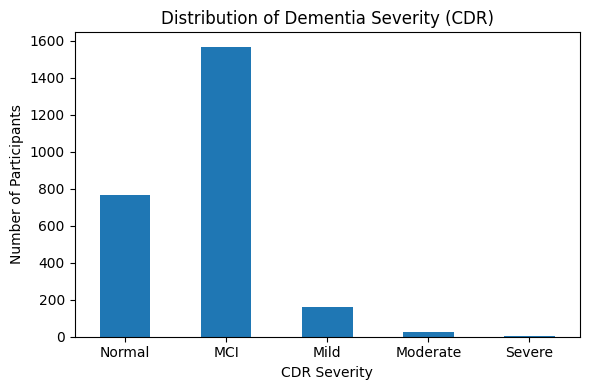

In [196]:
import matplotlib.pyplot as plt

counts = pd.Series(cdr).value_counts().loc[order]

plt.figure(figsize=(6,4))
counts.plot(kind="bar")

plt.xlabel("CDR Severity")
plt.ylabel("Number of Participants")
plt.title("Distribution of Dementia Severity (CDR)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


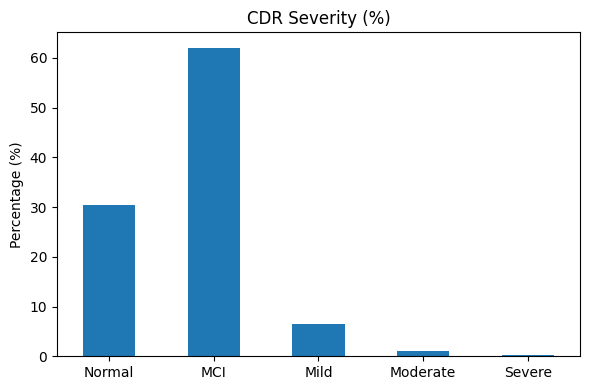

In [198]:
percent = counts / counts.sum() * 100

plt.figure(figsize=(6,4))
percent.plot(kind="bar")

plt.ylabel("Percentage (%)")
plt.title("CDR Severity (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


In [199]:
import numpy as np
import pandas as pd

# --------------------------------
# 1. Clean CDR
# --------------------------------
cdr = raw_data["r1cdr_final"].replace({
    "0.None": "Normal",
    0.5: "MCI",
    "1.Mild": "Mild",
    "2.Moderate": "Moderate",
    "3.Severe": "Severe"
})

# --------------------------------
# 2. Keep only Normal + MCI
# --------------------------------
mask = cdr.isin(["Normal","MCI"])

X = data.loc[mask].copy()
y = cdr.loc[mask]

# --------------------------------
# 3. Convert to numeric
# --------------------------------
y_num = (y == "MCI").astype(int)

X["MCI_target"] = y_num


# --------------------------------
# 4. Correlation
# --------------------------------
corr = X.corr(numeric_only=True)["MCI_target"].sort_values(ascending=False)

print("\nTop positive correlations (higher → more MCI):\n")
print(corr.head(10))

print("\nTop negative correlations (protective):\n")
print(corr.tail(10))



Top positive correlations (higher → more MCI):

MCI_target    1.000000
r1hcesdl10    0.220815
r1anx5        0.198361
r1hagey       0.095813
r1alp         0.084506
r1ast         0.041105
r1hpulse      0.016609
r1hsysto      0.005723
r1platelet   -0.029230
r1hdiasto    -0.051541
Name: MCI_target, dtype: float64

Top negative correlations (protective):

r1word_totaz   -0.249191
r1word_dz      -0.255623
r1rv_scorez    -0.264986
r1bvsp         -0.273422
r1blangf       -0.320330
r1borient      -0.370208
r1bexefu       -0.370614
r1bmemory      -0.382722
r1hmse_scorz   -0.411425
r1sgcp         -0.415149
Name: MCI_target, dtype: float64


/tmp/ipython-input-1442230254.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  cdr = raw_data["r1cdr_final"].replace({


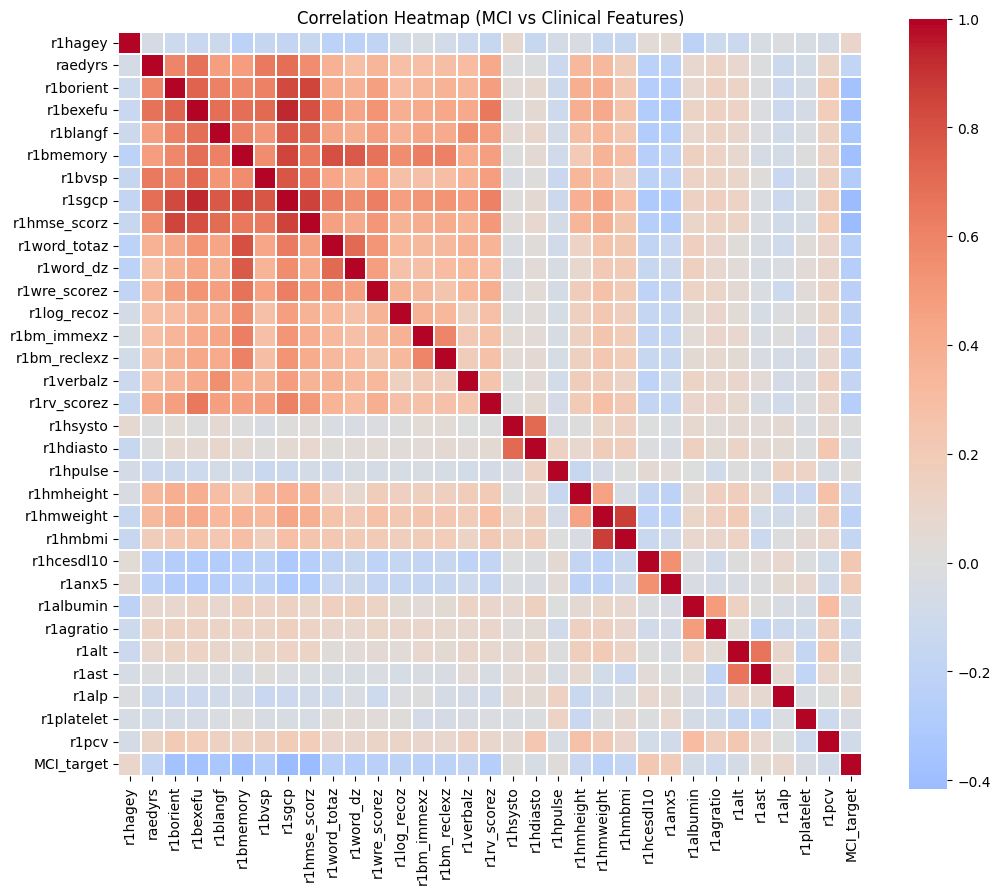

In [200]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3
)

plt.title("Correlation Heatmap (MCI vs Clinical Features)")
plt.show()


Feature ranking (most important)

In [201]:
corr_target = corr_matrix["MCI_target"].drop("MCI_target")

ranking = corr_target.abs().sort_values(ascending=False)

print("\n=== Feature Importance Ranking (|correlation|) ===\n")
print(ranking)



=== Feature Importance Ranking (|correlation|) ===

r1sgcp          0.415149
r1hmse_scorz    0.411425
r1bmemory       0.382722
r1bexefu        0.370614
r1borient       0.370208
r1blangf        0.320330
r1bvsp          0.273422
r1rv_scorez     0.264986
r1word_dz       0.255623
r1word_totaz    0.249191
r1wre_scorez    0.233555
r1bm_immexz     0.229281
r1bm_reclexz    0.224003
r1hcesdl10      0.220815
r1hmweight      0.217319
r1log_recoz     0.214239
r1anx5          0.198361
raedyrs         0.181588
r1verbalz       0.174781
r1hmbmi         0.167169
r1hmheight      0.141807
r1agratio       0.106870
r1hagey         0.095813
r1pcv           0.084771
r1alp           0.084506
r1albumin       0.076018
r1alt           0.059798
r1hdiasto       0.051541
r1ast           0.041105
r1platelet      0.029230
r1hpulse        0.016609
r1hsysto        0.005723
Name: MCI_target, dtype: float64


Interpretation of Correlation between Clinical Variables and Mild Cognitive Impairment (MCI)

To examine the association between Mild Cognitive Impairment (MCI) and selected clinical variables, Pearson’s correlation coefficients were computed between the binary outcome variable (MCI = 1, Normal = 0) and all predictor variables. The absolute magnitude of correlation was used to rank the importance of predictors.

1. Strong positive correlations (r ≥ 0.35)

The highest correlations were observed for global cognitive performance measures:

r1sgcp (Global cognitive performance score) — 0.415

r1hmse_scorz (Standardized HMSE score) — 0.411

r1bmemory (Memory function) — 0.383

r1bexefu (Executive function) — 0.371

r1borient (Orientation ability) — 0.370

These variables demonstrate strong associations with MCI status, indicating that deterioration in overall cognitive functioning, memory, executive processes, and orientation are the most influential predictors of early cognitive impairment. This finding is consistent with established clinical knowledge that cognitive test scores are the primary diagnostic indicators of dementia and related disorders.

2. Moderate correlations (0.20 ≤ r < 0.35)

Several domain-specific cognitive measures and psychological factors showed moderate relationships:

Language function (r1blangf)

Visuospatial ability (r1bvsp)

Verbal recall and word recognition scores

Depression scale (r1hcesdl10)

Anxiety score (r1anx5)

These results suggest that deficits in specific neuropsychological domains and the presence of depressive or anxiety symptoms are moderately associated with MCI. Emotional distress may exacerbate cognitive dysfunction or reflect early manifestations of neurodegeneration.

3. Weak correlations (0.10 ≤ r < 0.20)

Variables such as:

Education years (raedyrs)

Body Mass Index (r1hmbmi)

Weight and height measures

showed weaker associations.

Education likely reflects cognitive reserve, where individuals with fewer years of schooling may be more vulnerable to cognitive decline. Anthropometric measures may represent general health or frailty rather than direct cognitive determinants.

4. Very weak or negligible correlations (r < 0.10)

Biochemical and physiological markers, including:

Blood pressure (systolic/diastolic)

Pulse rate

Liver enzymes (ALT, AST, ALP)

Platelet count

Albumin and other laboratory parameters

demonstrated minimal linear association with MCI.

These findings imply that laboratory indicators have limited direct influence on immediate cognitive performance and may instead act as indirect or long-term risk factors.

Overall Interpretation

The analysis reveals that:

Cognitive performance measures are the strongest predictors of MCI.

Psychological factors such as depression and anxiety show moderate influence.

Demographic and physical health variables exhibit weaker associations.

Laboratory biomarkers have minimal direct correlation.

Thus, the results support the clinical understanding that cognitive assessment scores are the most reliable indicators of early cognitive impairment, while physiological and biochemical measures play a secondary role.